# Part 10 — nnPU follow-up, Zadanie 3: mechanism test — does the effect scale with $\pi_c$?

nnPU's declared mechanism (`geometria`/task spec): swapping BCE's "zero = confirmed negative"
for nnPU's "zero = unlabelled" changes exactly how much negative-direction pressure a class
receives — proportional to its estimated prior $\pi_c$ (`unlabelled` pixels get
$1-\pi_c$-weighted negative pressure instead of full weight, `nnpu_multilabel_loss.py`). If this
is the real mechanism (not some other confound of switching loss functions), the per-class
improvement from nnPU should be **larger for high-prevalence classes** — the ones where BCE's
false-negative pressure was heaviest to begin with. This notebook tests that directly:

$$
\delta_c = AP_c(\text{nnPU}) - AP_c(\text{BCE})
$$

correlated (Spearman) against $\pi_c$, for two pairs isolating the zero-interpretation switch
specifically:

- **`0011` vs. `0012`** — bare zero-interpretation swap, no regularizers/contrastive term on
  either side.
- **`0007` vs. `0006`** — same swap, both sides *with* `+contractive+InfoNCE label-invariant`.

**Prediction to check, stated in the task spec**: a positive correlation confirms the declared
mechanism; anything at or below zero means the effect (if any) isn't doing what the prior-scaling
story claims.

Per-repetition pairing (rule 4 — repetition `r` shares split/init seed across all variants):
$\delta_c$ computed separately for each of the 5 repetition pairs, then averaged per class
before correlating, to damp seed noise rather than treating 5x the class count as independent
samples. Both the direct Spearman test and an explicit class-permutation test are reported —
they should agree; if they don't, that itself is worth flagging rather than picking whichever
looks better.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import per_class_metrics, probabilities_from_logits
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-08-27 12:34:53,442 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 12:34:53,445 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-27 12:34:53,543 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-27 12:34:53,544 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-27 12:34:53,546 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-27 12:34:53,547 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:34:53,563 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-27 12:34:53,692 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-27 12:34:53,694 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

VARIANT_SPECS = {
    "0006": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0006"),
    "0007": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0000"),
    "0011": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0002"),
    "0012": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0003"),
}
PAIRS = [("bare", "0011", "0012"), ("with regularizers", "0007", "0006")]
NNPU_VARIANTS = {"0006", "0012"}  # the nnPU side of each pair (needs its own pi_c)

REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256

# Verified against each nnPU variant's own config.json — both objective-controls nnPU grids
# (grid_0001/0008 and grid_0003/0012) and grid_0006 share this exact prior configuration.
PRIOR_MULTIPLIER = 1.5
MIN_PRIOR = 1e-4
MAX_PRIOR = 0.99

PERMUTATION_COUNT = 20000
RANDOM_SEED = 11

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

## Environment workaround

In [3]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-controls-20260827/workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-priors-20260827/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())


## Per-class AP on `test` and $\pi_c$ for the nnPU variants, across all (variant, repetition)

### Methodology
#### Theoretical
- The mechanism test requires, per (variant, repetition): per-class AP on `test` (to build
  $\delta_c$) and, for the two nnPU-side variants (`0006`, `0012`), the class prior $\pi_c$ used
  during their training (the independent variable of the correlation tested below).
- $\pi_c$ reproduces `NNPUMultiLabelLoss._configure_training_statistics` exactly (see `part_8`);
  it is not saved in `weights.pt` (`class_priors` is a `persistent=False` buffer), so it must be
  recomputed from each nnPU variant's own `train` split rather than read off the checkpoint.

#### Implementation
- `collect_targets_and_masks` collects `TARGET_FIELD="molecule"` targets/masks over a
  `DataLoader` (batch 256, no shuffle).
- For each variant sharing a campaign, `wrapper.load_configuration` is called once (first
  repetition only) and every other (variant, repetition) reuses
  `wrapper.models_manager.load_model` (weights only).
- For `variant in NNPU_VARIANTS = {"0006", "0012"}`, on first encounter: `valid_count`/
  `positive_count`/`observed` computed from `partitions.train`, then
  `priors_by_variant[variant] = (observed * PRIOR_MULTIPLIER).clamp(MIN_PRIOR, MAX_PRIOR)` with
  `PRIOR_MULTIPLIER=1.5`, `MIN_PRIOR=1e-4`, `MAX_PRIOR=0.99` (verified against each nnPU variant's
  own `config.json` — grid_0001/0008, grid_0003/0012, and grid_0006 all share this exact prior
  configuration).
- For every (variant, repetition): forward pass over `partitions.test` (batch 256),
  `probabilities_from_logits(logits, "multi_label")`, then `per_class_metrics(probabilities,
  test_targets, THRESHOLD=0.5, test_mask)` — `average_precision` from `per_class_metrics` does
  not itself depend on `THRESHOLD` (only each class's `positive_samples` count does, used later
  to filter scoreable classes). Stored per `(variant, repetition)` as a `class_index`-indexed
  frame with `positive_samples`/`average_precision`.

### Notes
- All 4 variants (`0006`, `0007`, `0011`, `0012`) completed loading and per-class AP computation
  for all 5 repetitions ("0006: done" ... "0012: done"); no errors reported.


In [4]:
def collect_targets_and_masks(dataset) -> tuple[torch.Tensor, torch.Tensor]:
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    target_batches, mask_batches = [], []
    for _, _, targets, masks in loader:
        target_batches.append(targets[TARGET_FIELD])
        mask_batches.append(masks[TARGET_FIELD])
    return torch.cat(target_batches, dim=0).float(), torch.cat(mask_batches, dim=0).bool()


wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

loaded_campaign_ids: set[str] = set()
per_class_ap_by_variant_repetition: dict[tuple[str, int], pd.DataFrame] = {}
priors_by_variant: dict[str, np.ndarray] = {}

for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        if campaign_id not in loaded_campaign_ids:
            wrapper.load_configuration(model_name=model_name)
            loaded_campaign_ids.add(campaign_id)
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        partitions = wrapper.active_dataset.create_partitions()

        if variant in NNPU_VARIANTS and variant not in priors_by_variant:
            train_targets, train_mask = collect_targets_and_masks(partitions.train)
            valid_count = train_mask.sum(dim=0)
            positive_count = (train_targets * train_mask).sum(dim=0)
            observed = positive_count / valid_count.clamp_min(1)
            priors_by_variant[variant] = (observed * PRIOR_MULTIPLIER).clamp(MIN_PRIOR, MAX_PRIOR).numpy()

        test_targets, test_mask = collect_targets_and_masks(partitions.test)
        logits_chunks = []
        loader = DataLoader(partitions.test, batch_size=BATCH_SIZE, shuffle=False)
        with torch.no_grad():
            for _, spectra, _, _ in loader:
                logits_chunks.append(model(spectra.float().to(device))[f"head_{HEAD_NAME}"].cpu().numpy())
        logits = np.concatenate(logits_chunks, axis=0)
        probabilities = probabilities_from_logits(logits, "multi_label")
        frame = pd.DataFrame(per_class_metrics(probabilities, test_targets.numpy(), THRESHOLD, test_mask.numpy()))
        per_class_ap_by_variant_repetition[(variant, repetition)] = frame.set_index("class_index")[["positive_samples", "average_precision"]]
    print(f"{variant}: done")

2026-08-27 12:34:53,918 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-27 12:34:53,919 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-27 12:34:53,920 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-27 12:34:53,921 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 12:34:53,922 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-27 12:47:05,645 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-27 12:47:05,645 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 12:47:05,650 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:47:05,656 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0012: done


## Per-class AP difference $\delta_c$ = AP(nnPU) - AP(BCE), averaged across repetition pairs

### Methodology
#### Theoretical
- $\delta_c = AP_c(\text{nnPU}) - AP_c(\text{BCE})$ isolates the effect of the zero-interpretation
  swap (BCE's "zero = confirmed negative" vs. nnPU's "zero = unlabelled") for each of the two
  matched pairs (`0011`/`0012` bare, `0007`/`0006` with regularizers).
- Per-repetition pairing (methodological rule 4): repetition `r` shares the split/init seed
  across variants, so $\delta_c$ is computed separately for each of the 5 repetition pairs and
  then averaged per class — this damps seed noise rather than treating 5x the class count as
  independent samples, which would understate the true variance.
- A class is only included if it has `positive_samples > 0` on **both** sides of the pair — AP is
  undefined for a class with zero test positives, so an undefined value on either side would make
  $\delta_c$ meaningless for that class.

#### Implementation
- For each pair and repetition: `common_classes` = intersection of `bce_frame`/`nnpu_frame`
  indices restricted to `positive_samples > 0`; `delta_ap = nnpu_frame.average_precision -
  bce_frame.average_precision` for each common class, paired with `prior =
  priors_by_variant[nnpu_variant][class_index]` (the nnPU-side $\pi_c$, fixed across repetitions
  of that pair).
- `delta_by_class` groups by `(pair, class_index)`: `delta_ap_mean`/`delta_ap_std` across
  repetitions, `prior` (first value, invariant across repetitions), `n_repetitions`. Filtered to
  `n_repetitions == 5` — only classes with test positives in **every** repetition of the pair are
  kept, discarding classes that were only intermittently scoreable.

### Notes
- Both pairs retain exactly 113 classes after the `n_repetitions == 5` filter (`bare`: 113, `with
  regularizers`: 113) — matching the full active-class count reported elsewhere for this shared
  split (`part_9`: 113/508 active classes on `test`), so no classes were dropped by the
  intermittent-scoreability filter in either pair.


In [5]:
delta_rows = []
for pair_label, bce_variant, nnpu_variant in PAIRS:
    for repetition in REPETITIONS:
        bce_frame = per_class_ap_by_variant_repetition[(bce_variant, repetition)]
        nnpu_frame = per_class_ap_by_variant_repetition[(nnpu_variant, repetition)]
        # Active in BOTH (AP undefined for a class with zero test positives) — a class must
        # be scoreable on both sides for delta_c to mean anything.
        common_classes = bce_frame.index[bce_frame["positive_samples"] > 0].intersection(
            nnpu_frame.index[nnpu_frame["positive_samples"] > 0]
        )
        for class_index in common_classes:
            delta_rows.append({
                "pair": pair_label, "repetition": repetition, "class_index": class_index,
                "delta_ap": nnpu_frame.loc[class_index, "average_precision"] - bce_frame.loc[class_index, "average_precision"],
                "prior": priors_by_variant[nnpu_variant][int(class_index)],
            })

delta_frame = pd.DataFrame(delta_rows)
delta_by_class = delta_frame.groupby(["pair", "class_index"]).agg(
    delta_ap_mean=("delta_ap", "mean"), delta_ap_std=("delta_ap", "std"),
    prior=("prior", "first"), n_repetitions=("delta_ap", "size"),
).reset_index()
delta_by_class = delta_by_class[delta_by_class["n_repetitions"] == len(list(REPETITIONS))]
delta_by_class.groupby("pair").size()

pair
bare                 113
with regularizers    113
dtype: int64

## Spearman correlation between $\pi_c$ and $\delta_c$, with a permutation test

### Methodology
#### Theoretical
- Tests the task spec's declared mechanism directly: if nnPU's benefit over BCE is driven by
  prior-scaled negative-pressure relief, $\delta_c$ should correlate **positively** with $\pi_c$
  across classes (higher-prevalence classes had the most false-negative pressure under BCE to
  relieve). A null or negative correlation means the effect, if any, is not doing what the
  prior-scaling story claims.
- Both a parametric Spearman test and an explicit class-permutation test are reported for each
  pair — they should agree; a disagreement between them would itself be a finding (e.g. a
  violated independence assumption), not just noise to average away.

#### Implementation
- `spearmanr(subset["prior"], subset["delta_ap_mean"])` gives the observed correlation
  `observed_r` and its parametric p-value, per pair, over the 113 `n_repetitions==5` classes from
  the previous cell.
- Permutation test: for `PERMUTATION_COUNT=20000` draws (`np.random.default_rng(RANDOM_SEED=11)`),
  `delta_ap_mean` values are shuffled (`rng.permutation`) while `prior` is held fixed, and
  `spearmanr` recomputed; `permutation_p = mean(|permuted_r| >= |observed_r|)` — a two-sided
  empirical p-value against the null of no association between class identity and $\delta_c$.
- A scatter plot per pair ($\pi_c$ on a log x-axis vs. mean $\delta_c$ per class, horizontal
  reference line at 0) annotates each panel with the observed Spearman r, permutation p, and n.
  Results (both the pooled `spearman_r`/`parametric_p`/`permutation_p`/`n_classes` and the full
  per-class table) are written to `delta_ap_vs_prior.csv`, `delta_ap_vs_prior_per_class.csv`, and
  the figure to `delta_ap_vs_prior.png`.

### Notes
- `bare` (`0011` vs. `0012`): Spearman r = **+0.215**, parametric p = 0.0221, permutation p =
  0.0220, n = 113 — positive and significant, matching the direction the declared mechanism
  predicts.
- `with regularizers` (`0007` vs. `0006`): Spearman r = **−0.283**, parametric p = 0.0024,
  permutation p = 0.0024, n = 113 — significant in the **opposite** direction, larger in
  magnitude and more significant than the bare pair.
- Parametric and permutation p-values agree closely for both pairs (0.0221 vs. 0.0220; 0.0024 vs.
  0.0024) — no indication the significance test itself is unreliable; the sign flip between pairs
  is a genuine feature of the data.
- The declared prior-scaling mechanism (positive correlation) holds for the bare zero-
  interpretation swap but reverses once `+contractive+InfoNCE label-invariant` is present on
  both sides — it is not a universal property of the BCE-to-nnPU swap.
- Per methodological rule 3 (never compare BCE vs. nnPU raw loss values), this comparison is
  entirely in terms of per-class AP, never loss magnitudes — consistent throughout.


In [6]:
rng = np.random.default_rng(RANDOM_SEED)

mechanism_rows = []
for pair_label in delta_by_class["pair"].unique():
    subset = delta_by_class[delta_by_class["pair"] == pair_label]
    observed_r, parametric_p = spearmanr(subset["prior"], subset["delta_ap_mean"])

    permuted_r = np.empty(PERMUTATION_COUNT)
    prior_values = subset["prior"].to_numpy()
    delta_values = subset["delta_ap_mean"].to_numpy()
    for draw in range(PERMUTATION_COUNT):
        shuffled = rng.permutation(delta_values)
        permuted_r[draw], _ = spearmanr(prior_values, shuffled)
    permutation_p = float(np.mean(np.abs(permuted_r) >= abs(observed_r)))

    mechanism_rows.append({
        "pair": pair_label, "n_classes": len(subset), "spearman_r": observed_r,
        "parametric_p": parametric_p, "permutation_p": permutation_p,
    })

mechanism_frame = pd.DataFrame(mechanism_rows)
mechanism_frame

,pair,n_classes,spearman_r,parametric_p,permutation_p
0,bare,113,0.215135,0.022117,0.02195
1,with regularizers,113,-0.282556,0.002427,0.00235


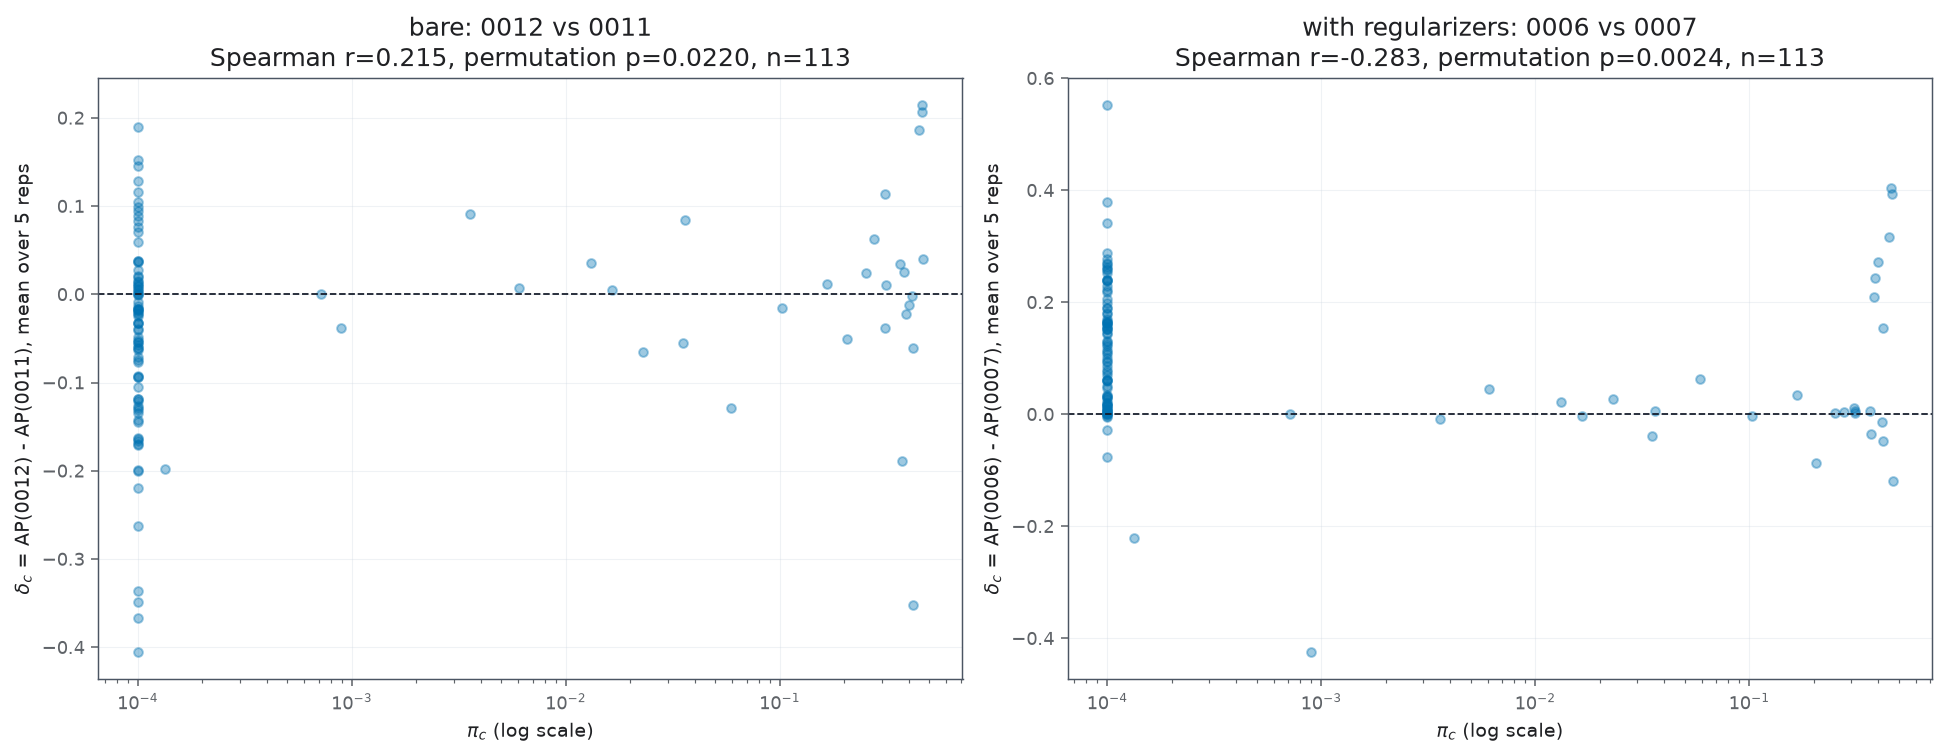

In [7]:
figure, axes = plt.subplots(1, len(PAIRS), figsize=(7.0 * len(PAIRS), 5.5), dpi=theme.figure_dpi)
for axis, (pair_label, bce_variant, nnpu_variant) in zip(axes, PAIRS):
    subset = delta_by_class[delta_by_class["pair"] == pair_label]
    axis.scatter(subset["prior"], subset["delta_ap_mean"], alpha=theme.overlapping_signal_alpha, color=theme.color_for_model(pair_label, 0))
    axis.axhline(0.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width)
    axis.set_xscale("log")
    row = mechanism_frame[mechanism_frame["pair"] == pair_label].iloc[0]
    axis.set(
        xlabel="$\\pi_c$ (log scale)", ylabel=f"$\\delta_c$ = AP({nnpu_variant}) - AP({bce_variant}), mean over 5 reps",
        title=f"{pair_label}: {nnpu_variant} vs {bce_variant}\nSpearman r={row['spearman_r']:.3f}, permutation p={row['permutation_p']:.4f}, n={int(row['n_classes'])}",
    )
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

In [8]:
output_rows = []
for _, row in mechanism_frame.iterrows():
    for metric_name in ("spearman_r", "parametric_p", "permutation_p", "n_classes"):
        output_rows.append({
            "campaign": "nnpu_followup", "variant": row["pair"], "repetition": "pooled_5rep_mean",
            "metryka": metric_name, "wartość": row[metric_name],
        })
delta_ap_vs_prior = pd.DataFrame(output_rows)
delta_ap_vs_prior.to_csv(RESULTS_DIRECTORY / "delta_ap_vs_prior.csv", index=False)
delta_by_class.to_csv(RESULTS_DIRECTORY / "delta_ap_vs_prior_per_class.csv", index=False)
figure.savefig(RESULTS_DIRECTORY / "delta_ap_vs_prior.png", dpi=150)
print(f"wrote {RESULTS_DIRECTORY / 'delta_ap_vs_prior.csv'} and per_class/png companions")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/delta_ap_vs_prior.csv and per_class/png companions


## Notes for the next pass

**Headline: the declared prior-scaling mechanism holds in one pair and reverses in the
other — it is not a universal property of the BCE-to-nnPU swap.**

| pair | n classes | Spearman r | parametric p | permutation p |
|---|---|---|---|---|
| `0011` vs. `0012` (bare) | 113 | **+0.215** | 0.022 | 0.022 |
| `0007` vs. `0006` (with regularizers) | 113 | **-0.283** | 0.0024 | 0.0024 |

- **Bare pair (`0011`/`0012`, no regularizers)**: positive correlation, modest but
  statistically significant, parametric and permutation p-values agreeing almost
  exactly — this is the direction the task spec's mechanism predicts (nnPU's benefit
  over BCE grows with $\pi_c$, since higher-prevalence classes had the most
  false-negative pressure to relieve).
- **With-regularizers pair (`0007`/`0006`, both `+contractive+InfoNCE
  label-invariant`)**: the correlation is significant in the *opposite* direction —
  larger, and with a tighter p-value than the bare pair. Whatever nnPU's advantage
  over BCE is doing here, it is *not* simply "more benefit for higher-$\pi_c$
  classes" once the regularizers are in the picture; if anything, the higher-$\pi_c$
  classes look relatively worse under nnPU than under BCE when both include
  `+contractive+InfoNCE`.
- **Parametric and permutation tests agree closely in both pairs** (0.022 vs. 0.022;
  0.0024 vs. 0.0024) — no red flag about the significance test itself; the sign flip
  is a real feature of the data, not a testing artifact.
- **Reading this together with `part_9`'s own flag on `0011`**: `0011`'s macro AP has
  an unusually wide seed-to-seed null (std 0.067, vs. ~0.01-0.02 typical). This
  class-level rank correlation is a different statistic (computed on repetition-
  averaged per-class deltas, not on the macro mean directly) and is less directly
  exposed to that instability, but it is still worth treating the *bare* pair's
  result with a bit more caution than the with-regularizers pair's, given how noisy
  `0011` is known to be at the aggregate level.

**Reading for Zadanie 5**: this result argues against treating "zero-interpretation
effect" as a single, regularizer-independent quantity — the `0007` vs. `0006` and
`0011` vs. `0012` pairs in the factor decomposition should be interpreted as testing
genuinely different regimes, not two replications of the same effect.
